# 03 — First Exploratory South Atlantic Anomaly Map (Checkpoint 3)

Build the **first exploratory** longitude/latitude proton-flux maps over the South America /
South Atlantic sector from the real NOAA-19 one-day table.

**This notebook is executed on NOAA data.**

> **Scientific scope.** These are **exploratory one-day proton-flux maps** for **pipeline
> validation only**. They are **NOT** the final shape of the South Atlantic Anomaly, do **NOT**
> measure biological dose, do **NOT** predict health risk, are **NOT** a discovery, and one day is
> **not** enough for a stable map. `mep_omni_flux_p1` is a differential proton flux (~25 MeV,
> `#/cm2-s-str-MeV`). Any elevated area is described only as a *candidate high-flux region in the
> South Atlantic / South America sector*.

In [1]:
import os, sys, pathlib
import numpy as np, pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

cwd = pathlib.Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(ROOT / "src"))

from saa.grid_flux import (prepare_region, grid_statistics, top_cells,
                           DEFAULT_LAT_RANGE, DEFAULT_LON_RANGE)
from saa.plot_maps import plot_heatmap

PARQUET = ROOT / "data" / "processed" / "noaa19_2024-01-01_mep_omni_flux_p1.parquet"
FIG = ROOT / "outputs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

CHANNEL = "mep_omni_flux_p1"
LAT_RANGE = DEFAULT_LAT_RANGE   # (-70, 20)
LON_RANGE = DEFAULT_LON_RANGE   # (-100, 20)

print("project root:", ROOT)
print("region: lat", LAT_RANGE, " lon", LON_RANGE)

project root: /home/fellipe/Projects/Active/saa-poes-mapping
region: lat (-70.0, 20.0)  lon (-100.0, 20.0)


## Step 1 — Load the processed one-day Parquet

In [2]:
df = pd.read_parquet(PARQUET)
print("rows loaded:", len(df))
print("longitude raw range [0,360): %.3f .. %.3f" % (df["lon"].min(), df["lon"].max()))
print("columns:", list(df.columns))
display(df.head())

rows loaded: 43197
longitude raw range [0,360): 0.007 .. 359.997
columns: ['time', 'lat', 'lon', 'alt', 'satellite', 'source_file', 'mep_omni_flux_p1', 'mep_IFC_on', 'mep_omni_flux_flag_fit']


,time,lat,lon,alt,satellite,source_file,mep_omni_flux_p1,mep_IFC_on,mep_omni_flux_flag_fit
0,2024-01-01 00:00:00.977000+00:00,71.722000,163.423996,855.5,noaa19,poes_n19_20240101_proc.nc,0.0211,-1,1
1,2024-01-01 00:00:02.977000+00:00,71.620003,163.229004,855.5,noaa19,poes_n19_20240101_proc.nc,0.0054,-1,1
2,2024-01-01 00:00:04.976000+00:00,71.517998,163.035995,855.5,noaa19,poes_n19_20240101_proc.nc,0.0000,-1,1
3,2024-01-01 00:00:06.976000+00:00,71.416000,162.845001,855.5,noaa19,poes_n19_20240101_proc.nc,0.0603,-1,1
4,2024-01-01 00:00:08.976000+00:00,71.313004,162.656006,855.5,noaa19,poes_n19_20240101_proc.nc,0.0599,-1,1


## Step 2 — Convert longitude to [-180, 180), filter region, apply calibration filter

Longitude is converted `[0,360) -> [-180,180)` **before** filtering. Region: lat -70..+20,
lon -100..+20 (South America + South Atlantic). Calibration filter: drop `mep_IFC_on == 1` only;
`-1` is undocumented and **kept / not interpreted**.

In [3]:
region, counts = prepare_region(df, LAT_RANGE, LON_RANGE)

print("row count BEFORE geographic filter:", counts["n_total"])
print("row count AFTER  geographic filter:", counts["n_after_geo"])
print()
print("row count BEFORE mep_IFC_on filter:", counts["n_after_geo"])
print("row count AFTER  mep_IFC_on filter:", counts["n_after_ifc"])
print("  dropped mep_IFC_on == 1 :", counts["n_ifc_on_dropped"])
print("  kept    mep_IFC_on == -1:", counts["n_ifc_minus1"], "(undocumented; NOT interpreted)")
print()
print("region lon180 range: %.3f .. %.3f" % (region["lon180"].min(), region["lon180"].max()))
print("region lat    range: %.3f .. %.3f" % (region["lat"].min(), region["lat"].max()))

row count BEFORE geographic filter: 43197
row count AFTER  geographic filter: 7244

row count BEFORE mep_IFC_on filter: 7244
row count AFTER  mep_IFC_on filter: 7244
  dropped mep_IFC_on == 1 : 0
  kept    mep_IFC_on == -1: 6791 (undocumented; NOT interpreted)

region lon180 range: -99.987 .. 19.986
region lat    range: -70.000 .. 19.991


## Step 3 — Summary of the selected channel within the region

In [4]:
print("channel:", CHANNEL, "= MEPED omni proton DIFFERENTIAL flux @ ~25 MeV [#/cm2-s-str-MeV]")
print("(particle flux for pipeline validation -- NOT a dose, NOT a health-risk quantity)")
print()
print("min  : %.5f" % region[CHANNEL].min())
print("max  : %.5f" % region[CHANNEL].max())
print("mean : %.5f" % region[CHANNEL].mean())
print(">0   : %d    zeros: %d" % (int((region[CHANNEL] > 0).sum()), int((region[CHANNEL] == 0).sum())))
display(region[[CHANNEL]].describe())

channel: mep_omni_flux_p1 = MEPED omni proton DIFFERENTIAL flux @ ~25 MeV [#/cm2-s-str-MeV]
(particle flux for pipeline validation -- NOT a dose, NOT a health-risk quantity)

min  : 0.00000
max  : 36.56870
mean : 3.35633
>0   : 7056    zeros: 188


,mep_omni_flux_p1
count,7244.000000
mean,3.356331
std,6.790361
min,0.000000
25%,0.018200
50%,0.106250
75%,2.661175
max,36.568699


## Step 4 — Build grids and the four exploratory maps

A) 5deg mean flux  B) 5deg median flux  C) 2deg mean flux  D) 5deg sample count.
Flux maps use a log10 color scale (labelled); empty cells are blank.

5deg grid: 432 cells, 206 non-empty
2deg grid: 2700 cells, 548 non-empty


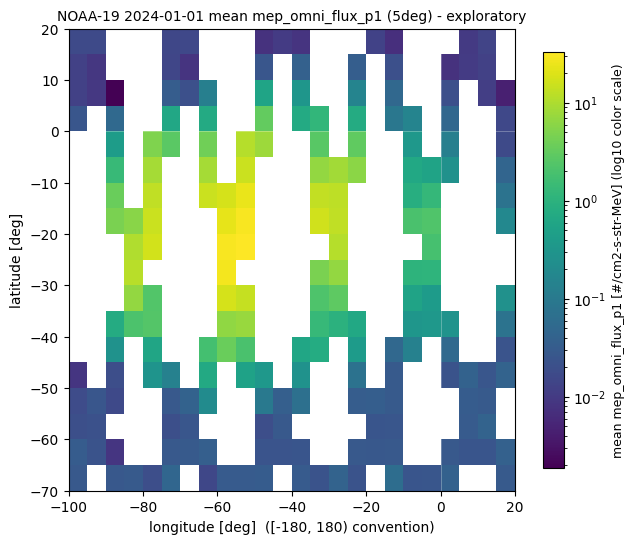

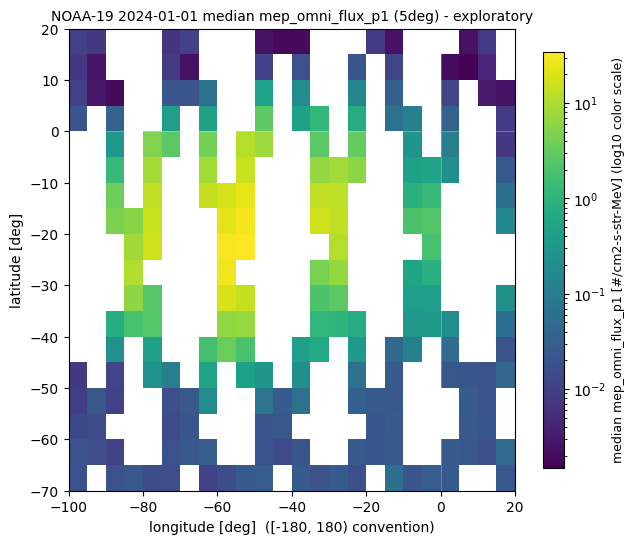

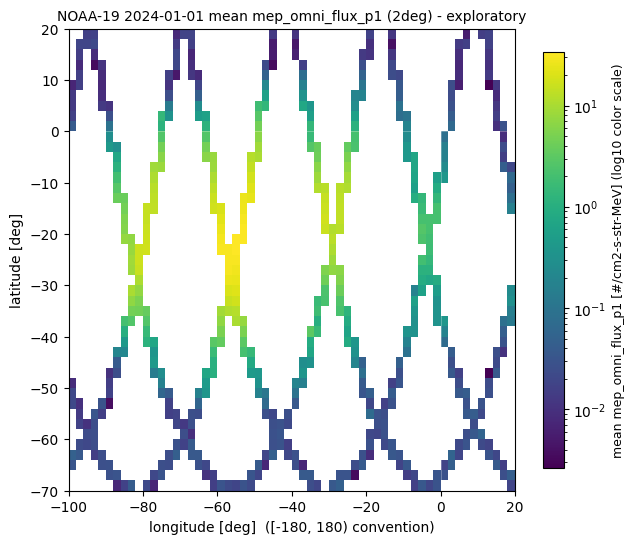

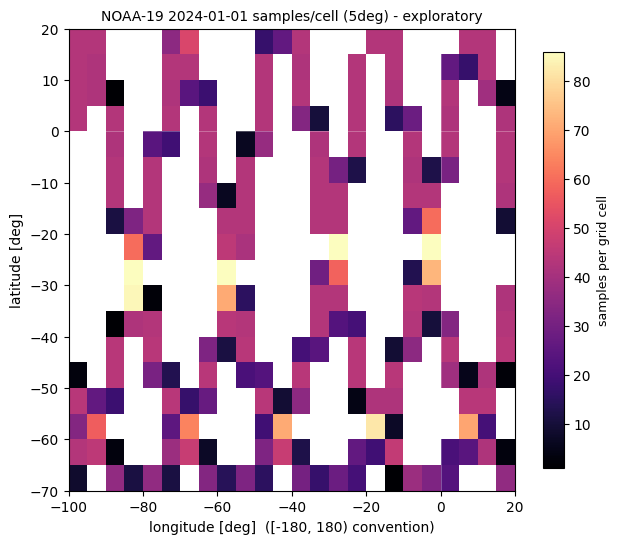

saved 4 figures to /home/fellipe/Projects/Active/saa-poes-mapping/outputs/figures


In [5]:
g5 = grid_statistics(region, CHANNEL, lat_step=5.0, lon_step=5.0, lat_range=LAT_RANGE, lon_range=LON_RANGE)
g2 = grid_statistics(region, CHANNEL, lat_step=2.0, lon_step=2.0, lat_range=LAT_RANGE, lon_range=LON_RANGE)
print("5deg grid: %d cells, %d non-empty" % (g5.n_cells, g5.n_nonempty))
print("2deg grid: %d cells, %d non-empty" % (g2.n_cells, g2.n_nonempty))

plot_heatmap(g5, "mean",   title="NOAA-19 2024-01-01 mean %s (5deg) - exploratory" % CHANNEL,
             save_path=str(FIG / "cp3_noaa19_2024-01-01_mean_flux_5deg.png"))
plot_heatmap(g5, "median", title="NOAA-19 2024-01-01 median %s (5deg) - exploratory" % CHANNEL,
             save_path=str(FIG / "cp3_noaa19_2024-01-01_median_flux_5deg.png"))
plot_heatmap(g2, "mean",   title="NOAA-19 2024-01-01 mean %s (2deg) - exploratory" % CHANNEL,
             save_path=str(FIG / "cp3_noaa19_2024-01-01_mean_flux_2deg.png"))
plot_heatmap(g5, "count",  title="NOAA-19 2024-01-01 samples/cell (5deg) - exploratory",
             save_path=str(FIG / "cp3_noaa19_2024-01-01_sample_count_5deg.png"))
plt.show()
print("saved 4 figures to", FIG)

## Step 5 — Top 10 grid cells (candidate high-flux footprint, exploratory)

In [6]:
print("Top 10 grid cells by MEAN flux (5deg):")
display(top_cells(g5, "mean", 10))
print("Top 10 grid cells by MEDIAN flux (5deg):")
display(top_cells(g5, "median", 10))

Top 10 grid cells by MEAN flux (5deg):


,lat_center,lon_center,mean,n_samples
0,-22.5,-52.5,33.137061,41
1,-22.5,-57.5,30.542551,45
2,-17.5,-52.5,30.193611,43
3,-27.5,-57.5,27.628106,86
4,-12.5,-52.5,23.584470,43
5,-17.5,-57.5,23.028570,43
6,-32.5,-57.5,17.851737,71
7,-12.5,-57.5,17.566617,6
8,-22.5,-77.5,16.845962,26
9,-17.5,-32.5,16.605079,43


Top 10 grid cells by MEDIAN flux (5deg):


,lat_center,lon_center,median,n_samples
0,-22.5,-52.5,34.477200,41
1,-22.5,-57.5,30.862700,45
2,-17.5,-52.5,30.421200,43
3,-27.5,-57.5,27.923000,86
4,-12.5,-52.5,23.341499,43
5,-17.5,-57.5,22.823000,43
6,-32.5,-57.5,18.868999,71
7,-12.5,-57.5,17.831600,6
8,-17.5,-32.5,16.739599,43
9,-22.5,-77.5,16.537500,26


## Step 6 — OPTIONAL multi-day preview (2024-01-01..07)

Downloads 6 more ~5 MB official files. **This checkpoint does not depend on it** — it only previews
that the multi-day path works; full multi-day mapping is deferred to Checkpoint 4.

7-day window: total rows 258692 -> region rows 43524  (files: 7)
7-day 5deg non-empty cells: 429  (one day was 206)


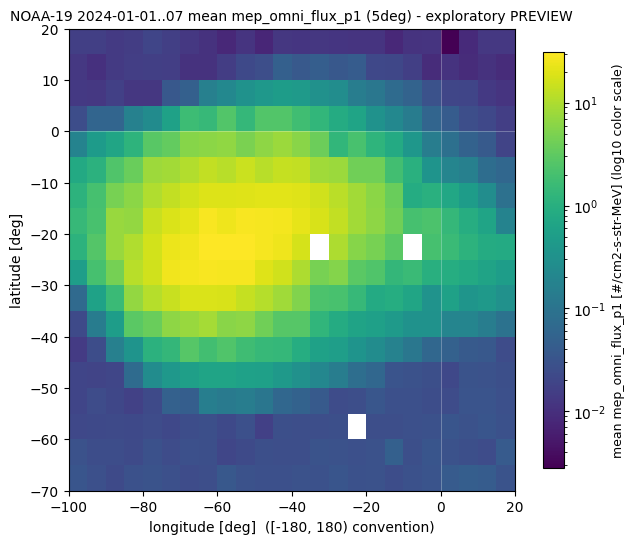

multi-day path works; full multi-day mapping -> Checkpoint 4.


In [7]:
try:
    from saa.load_poes import load_date_range
    df7, paths7 = load_date_range("2024-01-01", "2024-01-07", raw_dir=str(ROOT / "data" / "raw"))
    region7, counts7 = prepare_region(df7, LAT_RANGE, LON_RANGE)
    print("7-day window: total rows %d -> region rows %d  (files: %d)"
          % (len(df7), len(region7), len(paths7)))
    g5_7 = grid_statistics(region7, CHANNEL, 5.0, 5.0, LAT_RANGE, LON_RANGE)
    print("7-day 5deg non-empty cells: %d  (one day was %d)" % (g5_7.n_nonempty, g5.n_nonempty))
    plot_heatmap(g5_7, "mean",
                 title="NOAA-19 2024-01-01..07 mean %s (5deg) - exploratory PREVIEW" % CHANNEL,
                 save_path=str(FIG / "cp3_noaa19_2024-01-01_to_07_mean_flux_5deg.png"))
    plt.show()
    print("multi-day path works; full multi-day mapping -> Checkpoint 4.")
except Exception as e:
    print("multi-day preview skipped:", repr(e)[:160])
    print("-> implement the multi-day window in Checkpoint 4.")

## Summary (exploratory)

A real one-day NOAA-19 table was filtered to the South America / South Atlantic sector and binned
into lon/lat grids; a **candidate high-flux region** appears in the South Atlantic / South America
sector. These are **exploratory one-day proton-flux maps for pipeline validation** — **not** the
final SAA shape, **not** dose, **not** health risk, **not** a discovery, and **not** stable from a
single day. Validate the outputs with:

    python scripts/validate_cp3_outputs.py

Next (Checkpoint 4): aggregate a longer window (week -> month), add the sensitivity axes
(channel / threshold / grid resolution / satellite / time window), and quantify center/area/intensity.